<a href="https://colab.research.google.com/github/Angelorigo/MODELOS-ESTOCASTICOS/blob/main/18_Simulaci%C3%B3n_de_Variables_aleatorias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**ÁLVAREZ SERVÍN ÁNGEL RODRIGO**

##- MATEMÁTICA ALGORÍTMICA.
##- MODELOS ESTOCÁSTICOS.
##- ESFM IPN, MAYO 2026.

Este documento recopila todos los códigos utilizados para realizar las simulaciones de generación de variables aleatorias mediante el método de la transformada inversa, correspondientes a las distribuciones consideradas en la Actividad 4:

- **Weibull, $We$($\alpha$, 1)**.
- **Gumbel, $Gu(0, 1)$**.
- **Cauchy, $C(0, 1)$**.
- **Laplace, $L(0,1)$**.
- **Pareto, $Par$($\alpha$)**.

Asimismo, se incluyen las expresiones matemáticas de cada distribución en su forma inversa, utilizadas para la generación de las muestras aleatorias.

Adicionalmente, se realiza la verificación de las medidas estadísticas de media, varianza y desviación estándar para cada distribución. En el caso de las distribuciones de Cauchy y Pareto, dichas medidas no se consideran debido a que presentan valores infinitos o no definidos.

Finalmente, se presentan las gráficas correspondientes a los histogramas obtenidos en cada simulación.

Primero, añadimos las librerías a utilizar.

In [ ]:
import random as rnd
import numpy as np
import matplotlib.pyplot as plt

Ahora, observe el cálculo de las funciones inversas que después serán usadas en el programa, definiendo las funciones una por una de manera similar, conservando las especificaciones de cada una.

**Weibull, $We$($\alpha$, 1)**

Función Weibull con parámetros $(\alpha, 1)$ es:
$$F(x) = 1 - e^{-x^\alpha}, \quad x \ge 0$$
Sea $U \sim \mathcal{U}(0,1)$:
$$U = 1 - e^{-x^\alpha}$$
$$e^{-x^\alpha} = 1 - U$$
$$-x^\alpha = \ln(1 - U)$$
$$x = (-\ln(1 - U))^{1/\alpha}$$

In [ ]:
def weibull(alpha, n):
    muestra = []
    for i in range(n):
        U = rnd.random()
        X = (-np.log(1-U))**(1/alpha)
        muestra.append(X)
    return muestra

**Gumbel, $Gu(0, 1)$**

Función Gumbel con parámetros $(0, 1)$ es:
$$F(x) = e^{-e^{-x}}$$
Sea $U \sim \mathcal{U}(0,1)$:
$$U = e^{-e^{-x}}$$
$$\ln(U) = -e^{-x}$$
$$-\ln(U) = e^{-x}$$
$$\ln(-\ln(U)) = -x$$
$$x = -\ln(-\ln(U))$$


In [ ]:
def gumbel(n):
    muestra = []
    for i in range(n):
        U = rnd.random()
        X = -np.log(-np.log(U))
        muestra.append(X)
    return muestra

**Cauchy, $C(0, 1)$**

La CDF de Cauchy es:
$$F(x) = \frac{1}{\pi} \arctan(x) + \frac{1}{2}$$
Sea $U \sim \mathcal{U}(0,1)$:
$$U = \frac{1}{\pi} \arctan(x) + \frac{1}{2}$$
$$U - 0.5 = \frac{1}{\pi} \arctan(x)$$
$$\pi(U - 0.5) = \arctan(x)$$
$$x = \tan(\pi(U - 0.5))$$

In [ ]:
def cauchy(n):
    muestra = []
    for i in range(n):
        U = rnd.random()
        X = np.tan(np.pi*(U-0.5))
        muestra.append(X)
    return muestra

**Laplace, $L(0,1)$**

La Función de Laplace con parámetros $(0, 1)$ se divide en dos casos:
$$F(x) = \begin{cases} \frac{1}{2}e^x & \text{si } x < 0 \\ 1 - \frac{1}{2}e^{-x} & \text{si } x \ge 0 \end{cases}$$
Sea $U \sim \mathcal{U}(0,1)$.
Para $U < 0.5$ (corresponde a la rama $x < 0$):
$$U = \frac{1}{2}e^x \implies 2U = e^x \implies x = \ln(2U)$$
Para $U \ge 0.5$ (corresponde a la rama $x \ge 0$):
$$U = 1 - \frac{1}{2}e^{-x} \implies \frac{1}{2}e^{-x} = 1 - U \implies e^{-x} = 2(1 - U) \implies x = -\ln(2(1 - U))$$

In [ ]:
def laplace(n):
    muestra = []
    for i in range(n):
        U = rnd.random()
        if U < 0.5:
            X = np.log(2*U)
        else:
            X = -np.log(2*(1-U))
        muestra.append(X)
    return muestra

**Pareto, $Par$($\alpha$)**

La función de Pareto con parámetro de forma $\alpha$ (y escala $1$) es:
$$F(x) = 1 - x^{-\alpha}, \quad x \ge 1$$
Sea $U \sim \mathcal{U}(0,1)$:
$$U = 1 - x^{-\alpha}$$
$$x^{-\alpha} = 1 - U$$
$$x = (1 - U)^{-1/\alpha}$$

In [ ]:
def pareto(alpha, n):
    muestra = []
    for i in range(n):
        U = rnd.random()
        X = (1-U)**(-1/alpha)
        muestra.append(X)
    return muestra

Ahora sigamos con los parámetros que van a compartir, evitando redundancias.

In [ ]:
n = 1000
alpha = 2
#  Estos valores pueden ser alterados dependiendo de la necesidad del usuario.

Prosigamos con ls muestras.

In [ ]:
m_weibull = weibull(alpha, n)
m_gumbel = gumbel(n)
m_cauchy = cauchy(n)
m_laplace = laplace(n)
m_pareto = pareto(alpha, n)

Ahora, se hace el cálculo de Media, Varianza y Desviación Estándar para Weibull, Gumbel y Laplace para después imprimirlas.

In [ ]:
print("\n--- ESTADÍSTICAS ---")
print(f"Weibull -> Media: {np.mean(m_weibull):.4f}, Varianza: {np.var(m_weibull, ddof=1):.4f}, Desv. Est: {np.std(m_weibull, ddof=1):.4f}")
print(f"Gumbel  -> Media: {np.mean(m_gumbel):.4f}, Varianza: {np.var(m_gumbel, ddof=1):.4f}, Desv. Est: {np.std(m_gumbel, ddof=1):.4f}")
print(f"Laplace -> Media: {np.mean(m_laplace):.4f}, Varianza: {np.var(m_laplace, ddof=1):.4f}, Desv. Est: {np.std(m_laplace, ddof=1):.4f}\n")


--- ESTADÍSTICAS ---
Weibull -> Media: 0.8888, Varianza: 0.2201, Desv. Est: 0.4691
Gumbel  -> Media: 0.5175, Varianza: 1.6147, Desv. Est: 1.2707
Laplace -> Media: -0.0513, Varianza: 2.0573, Desv. Est: 1.4343



Finalmente, las gráficas de los histogramas de cada distribución.

Histograma de **Weibull, $We$($\alpha$, 1)**

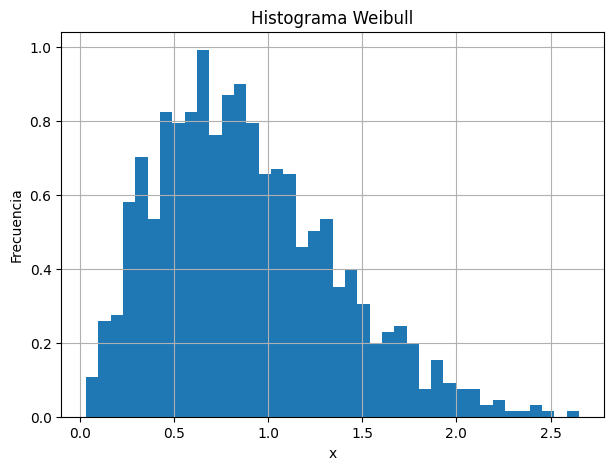

In [ ]:
plt.figure(figsize=(7,5))
plt.hist(m_weibull, bins=40, density=True)
plt.title("Histograma Weibull")
plt.xlabel("x")
plt.ylabel("Frecuencia")
plt.grid()
plt.show()

Histograma de **Gumbel, $Gu(0, 1)$**

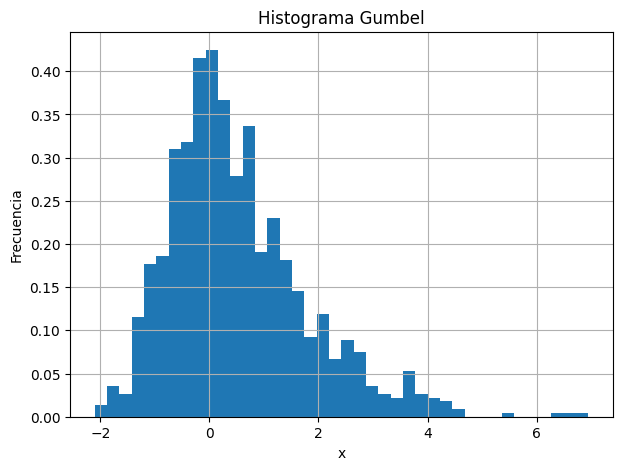

In [ ]:
plt.figure(figsize=(7,5))
plt.hist(m_gumbel, bins=40, density=True)
plt.title("Histograma Gumbel")
plt.xlabel("x")
plt.ylabel("Frecuencia")
plt.grid()
plt.show()

Histograma de **Cauchy, $C(0, 1)$**

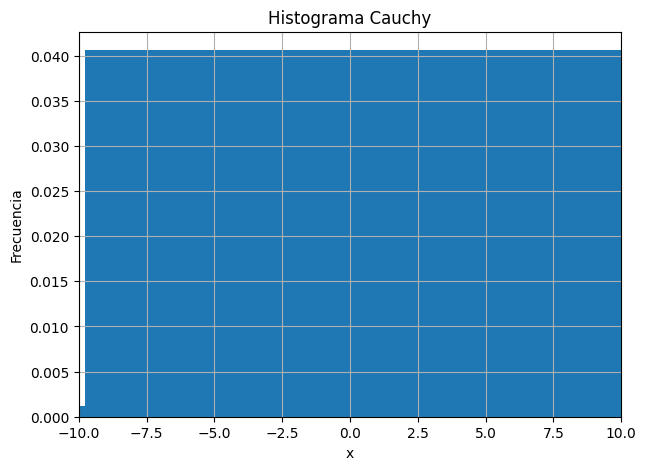

In [ ]:
plt.figure(figsize=(7,5))
plt.hist(m_cauchy, bins=100, density=True)
plt.xlim(-10,10)
plt.title("Histograma Cauchy")
plt.xlabel("x")
plt.ylabel("Frecuencia")
plt.grid()
plt.show()

Histograma de **Laplace, $L(0,1)$**

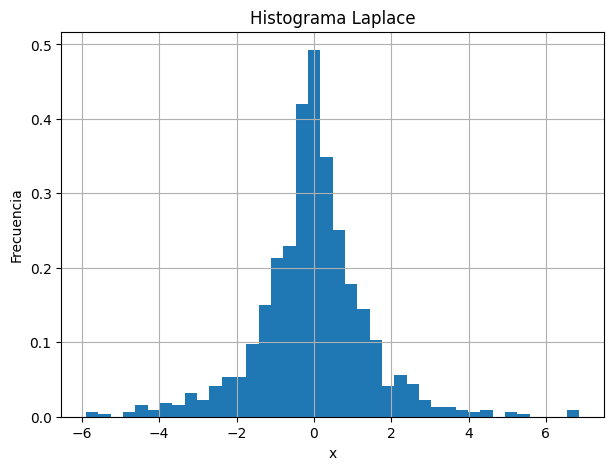

In [ ]:
plt.figure(figsize=(7,5))
plt.hist(m_laplace, bins=40, density=True)
plt.title("Histograma Laplace")
plt.xlabel("x")
plt.ylabel("Frecuencia")
plt.grid()
plt.show()

Histograma de **Pareto, $Par$($\alpha$)**.

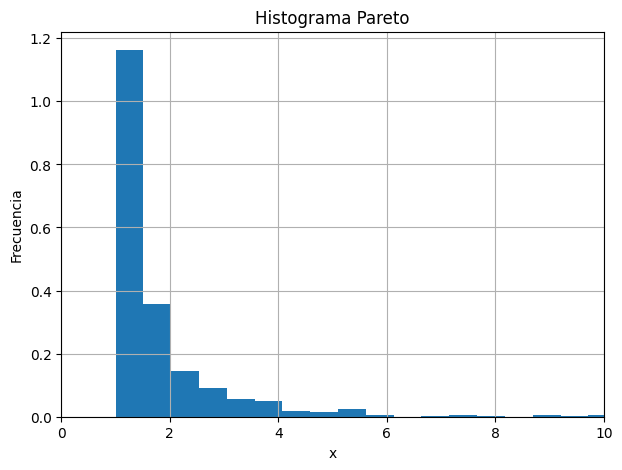

In [ ]:
plt.figure(figsize=(7,5))
plt.hist(m_pareto, bins=40, density=True)
plt.xlim(0,10)
plt.title("Histograma Pareto")
plt.xlabel("x")
plt.ylabel("Frecuencia")
plt.grid()
plt.show()